# Composure

**Composure** measures how well a pitcher maintains their composure in a variety of unfortunate situations.

The score is an aggregation of 14 component statistics, each measuring the rate of an undesirable outcome (walk, ball) following a specific trigger event. All components are normalized within the season and inverted so that **higher = better composure**. Composure+ acts as any other *plus* metric, normalizing player results where a Composure+ of 100 is league average

## Notebook structure

| Phase | What runs | Re-run when... |
|---|---|---|
| **0 — Config** | Thresholds, weights, normalization method | Any parameter change |
| **1 — Data pull** | Fetch pitch-by-pitch from Baseball Savant | New season / first run  |
| **2 — Metric computation** | Compute raw per-pitcher rates from parquet | Changing thresholds or metric definitions |
| **3 — Scoring** | Apply weights + normalization, save results | Changing weights or normalization only |

---
## Metric Definitions

Each metric is a **conditional rate**: given that event X occurred in the previous plate appearance (or the previous pitch), how often does the pitcher produce outcome Y?

---

### After Hard Contact — walks

| Metric | Trigger | Outcome | Intuition |
|---|---|---|---|
| `walk_after_barrel` | Previous PA: barrel hit (`launch_speed_angle == 6`) | Next PA: walk or HBP | Did giving up the hardest possible contact cause a loss of command? |
| `walk_after_hard_hit` | Previous PA: exit velo ≥ `HARD_HIT_MPH` (default 90 mph) | Next PA: walk or HBP | Broader hard-contact trigger — any well-struck ball |
| `walk_after_high_xba` | Previous PA: xBa ≥ `HIGH_XBA` (default .450) | Next PA: walk or HBP | Quality-of-contact trigger using expected stats rather than raw velo |

### After Hard Contact — immediate balls

| Metric | Trigger | Outcome | Intuition |
|---|---|---|---|
| `first_ball_after_barrel` | Previous PA: barrel | First pitch of next PA: ball | Quickest possible composure check — did the pitcher come out attacking? |
| `first_ball_after_hard_hit` | Previous PA: exit velo ≥ `HARD_HIT_MPH` | First pitch of next PA: ball | Same idea, broader hard-contact trigger |
| `first_ball_after_high_xba` | Previous PA: xBa ≥ `HIGH_XBA` | First pitch of next PA: ball | Expected-stats version |

---

### After Unlucky Soft Contact — walks
Soft contact is considered *unlucky* based on the expected batting average (xBA) of an event

| Metric | Trigger | Outcome |
|---|---|---
| `walk_after_soft_hit` | Previous PA: exit velo < `SOFT_HIT_MPH` (default 80 mph) | Next PA: walk or HBP |
| `walk_after_low_xba` | Previous PA: xBa < `LOW_XBA` (default .300) | Next PA: walk or HBP |

### After Unlucky Soft Contact — immediate balls

| Metric | Trigger | Outcome |
|---|---|---|
| `first_ball_after_soft_hit` | Previous PA: exit velo < `SOFT_HIT_MPH` | First pitch of next PA: ball |
| `first_ball_after_low_xba` | Previous PA: xBa < `LOW_XBA` | First pitch of next PA: ball |

---

### Additional Metrics

| Metric | Trigger | Outcome |
|---|---|---|
| `hard_hit_after_walk` | Previous PA: walk or HBP | Next PA: exit velo ≥ `HARD_HIT_MPH` |
| `hard_hit_after_soft` | Previous PA: exit velo < `SOFT_HIT_MPH` | Next PA: exit velo ≥ `HARD_HIT_MPH` |
| `walk_after_walk` | Previous PA: walk or HBP | Next PA: walk or HBP |
| `ball_after_foul` | Current PA: foul on pitch N | Pitch N+1 (same PA): ball |

---

### Classification rules
- **Barrel** = `launch_speed_angle == 6` (Based on the statcast classification)
- **Foul tip** → excluded from `ball_after_foul` trigger

---
## Phase 0 — Config & Setup

In [221]:
%pip install pybaseball

Note: you may need to restart the kernel to use updated packages.


In [222]:
import os, requests
import pandas as pd
import numpy as np
from tqdm import tqdm
import pybaseball
from pybaseball import statcast_single_game, playerid_reverse_lookup
import warnings
warnings.filterwarnings('ignore')
pybaseball.cache.enable()

import subprocess
_git_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], cwd=os.path.abspath(".")).decode().strip()
_nb_dir = os.path.join(_git_root, "composure")
DATA_DIR = os.path.join(_nb_dir, "data")
RESULTS_DIR = os.path.join(_nb_dir, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

SEASONS = [2021, 2022, 2023, 2024, 2025]

# ── Metric thresholds (re-run Phase 2 if you change these) ───────────────────
HARD_HIT_MPH  = 100     
SOFT_HIT_MPH  = 85    
HIGH_XBA      = 0.550  
LOW_XBA       = 0.250

# ── Pitcher qualification ─────────────────────────────────────────────────────
MIN_PITCHES = 500      # pitchers below this threshold are excluded from scoring

# ── Per-metric weights (re-run Phase 3 if you change these) ──────────────────
# Default 1.0 = equal contribution. Set to 0 to exclude a metric entirely.

# because walks are more impactful & indicative of composure, they have the highest weights,
# followed by the immediate ball result following an unlucky situation

WEIGHTS = {
    # After hard contact
    'walk_after_barrel':          2.0,
    'walk_after_hard_hit':        1.5,
    'walk_after_high_xba':        1.5,
    'first_ball_after_barrel':    0.5,
    'first_ball_after_hard_hit':  0.5,
    'first_ball_after_high_xba':  0.5,
    # After unlucky soft contact
    'walk_after_soft_hit':        2.5,
    'walk_after_low_xba':         2.5,
    'first_ball_after_soft_hit':  0.5,
    'first_ball_after_low_xba':   0.5,
    # Additional
    'hard_hit_after_walk':        0.25, # hard hits have additional context, should not be weighed as heavily
    'hard_hit_after_soft':        0.25,
    'walk_after_walk':            1.75, # back to back walks are a large indication of composure dropping
    'ball_after_foul':            .05,
}

METRIC_COLS = list(WEIGHTS.keys())

# ── Sub-score groupings (re-run Phase 3 if you change these) ─────────────────
# Adversity: after hard contact / walks — does the pitcher compound the damage?
ADVERSITY_METRICS = [
    'walk_after_barrel', 'walk_after_hard_hit', 'walk_after_high_xba',
    'first_ball_after_barrel', 'first_ball_after_hard_hit', 'first_ball_after_high_xba',
    'walk_after_walk', 'hard_hit_after_walk',
]
# Momentum: after lucky / soft contact — does the pitcher coast or stay sharp?
MOMENTUM_METRICS = [
    'walk_after_soft_hit', 'walk_after_low_xba',
    'first_ball_after_soft_hit', 'first_ball_after_low_xba',
    'hard_hit_after_soft', 'ball_after_foul',
]
# How to weight the two sub-scores when combining into overall composure_plus
ADVERSITY_WEIGHT = 1.0
MOMENTUM_WEIGHT  = 1.0

# ── Normalization method (re-run Phase 3 if you change this) ─────────────────
# 'zscore'     — (x - mean) / std across pitchers in the season
# 'percentile' — rank-based 0–1 percentile across pitchers
# 'minmax'     — rescale each metric to [0, 1] across pitchers
NORMALIZATION = 'zscore'

# ── Sample-size shrinkage (re-run Phase 3 if you change this) ────────────────
# Pseudo-observations added at the league average rate per metric group.
# Higher value = stronger pull toward league average for low-sample pitchers.
# Adversity triggers (barrels, hard hits) are rare → need stronger shrinkage.
# Momentum triggers (soft contact, fouls) are frequent → lighter shrinkage.
PRIOR_OBS_ADV = 40
PRIOR_OBS_MOM = 20

# ── Score confidence scaling (re-run Phase 3 if you change this) ─────────────
# Pitch count at which a pitcher reaches 50% confidence in their score.
# Below this: score pulled toward 100. Above: score stretches toward extremes.
# Raise to be more conservative; lower to trust smaller samples sooner.
SCORE_SCALE      = 50    # spread at full confidence: top pitcher ≈ 100 + z*SCORE_SCALE
CONFIDENCE_PRIOR = 1000  # pitch count at which confidence = 0.5; higher = more conservative

print(f'Config loaded. Data dir: {DATA_DIR}')
print(f'Normalization: {NORMALIZATION} | MIN_PITCHES: {MIN_PITCHES}')
print(f'Thresholds — hard hit: >={HARD_HIT_MPH} mph | soft: <{SOFT_HIT_MPH} mph | '
      f'high xBa: >={HIGH_XBA} | low xBa: <{LOW_XBA}')


Config loaded. Data dir: /Users/aryankapoor/Projects/Baseball/baseball/composure/data
Normalization: zscore | MIN_PITCHES: 500
Thresholds — hard hit: >=100 mph | soft: <85 mph | high xBa: >=0.55 | low xBa: <0.25


---
## Phase 1 — Data Pull

Fetches pitch-by-pitch Statcast data for each season via `pybaseball.statcast_single_game()` and saves the result to `data/all_pitches_YYYY.parquet`.

In [223]:
# ── Shared fetch helpers ──────────────────────────────────────────────────────

KEEP_COLS = [
    'game_pk', 'game_date', 'pitcher', 'player_name',  # player_name = batter
    'at_bat_number', 'pitch_number',
    'pitch_type', 'pitch_name', 'description', 'events',
    'launch_speed',            
    'launch_speed_angle',        
    'estimated_ba_using_speedangle', 
    'release_speed',
]
NUMERIC_COLS = [
    'launch_speed', 'launch_speed_angle', 'estimated_ba_using_speedangle',
    'at_bat_number', 'pitch_number', 'game_pk', 'release_speed',
]

def _normalize_raw(df):
    df = df[[c for c in KEEP_COLS if c in df.columns]].copy()
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    # game_date arrives as raw strings and may be mixed with NaN floats across
    # games — coerce to datetime so pyarrow can serialize the parquet cleanly.
    if 'game_date' in df.columns:
        df['game_date'] = pd.to_datetime(df['game_date'], errors='coerce')
    return df

def _fetch_game(game_pk):
    try:
        df = statcast_single_game(game_pk)
        return _normalize_raw(df) if (df is not None and not df.empty) else None
    except Exception as e:
        print(f'  Error {game_pk}: {e}')
        return None

def _get_game_pks(season):
    """Fetch all completed regular-season gamePks from the MLB Stats API."""
    teams = requests.get('https://statsapi.mlb.com/api/v1/teams?sportId=1').json()['teams']
    pks = set()
    for team in tqdm(teams, desc=f'{season} schedule', leave=False):
        sched = requests.get(
            f'https://statsapi.mlb.com/api/v1/schedule'
            f'?sportId=1&season={season}&teamId={team["id"]}&gameType=R'
        ).json()
        for date in sched.get('dates', []):
            for game in date.get('games', []):
                if game.get('status', {}).get('abstractGameState') == 'Final':
                    pks.add(game['gamePk'])
    return sorted(pks)

def pull_season(season):
    """Load pitch data from parquet cache if available, otherwise fetch and save."""
    path = os.path.join(DATA_DIR, f'all_pitches_{season}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f'{season}: loaded {len(df):,} pitches from cache.')
        return df
    pks = _get_game_pks(season)
    print(f'{season}: fetching {len(pks)} games...')
    results = [_fetch_game(pk) for pk in tqdm(pks, desc=str(season))]
    dfs = [r for r in results if r is not None]
    print(f'  {len(dfs)} ok / {len(pks) - len(dfs)} failed')
    df = pd.concat(dfs, ignore_index=True)
    df.to_parquet(path, index=False)
    print(f'  Saved → {path}')
    return df

print('Fetch helpers defined.')

Fetch helpers defined.


In [224]:
# ── 2021 data pull ────────────────────────────────────────────────────────────
pitches_2021 = pull_season(2021)

2021: loaded 712,320 pitches from cache.


In [225]:
# ── 2022 data pull ────────────────────────────────────────────────────────────
pitches_2022 = pull_season(2022)

2022: loaded 709,589 pitches from cache.


In [226]:
# ── 2023 data pull ────────────────────────────────────────────────────────────
pitches_2023 = pull_season(2023)

2023: loaded 720,684 pitches from cache.


In [227]:
# ── 2024 data pull ────────────────────────────────────────────────────────────
pitches_2024 = pull_season(2024)

2024: loaded 711,898 pitches from cache.


In [228]:
# ── 2025 data pull ────────────────────────────────────────────────────────────
pitches_2025 = pull_season(2025)

2025: loaded 712,528 pitches from cache.


---
## Phase 2 — Metric Computation

In [229]:
# ── Shared metric helpers ─────────────────────────────────────────────────────

def _add_flags(df):
    d = df.copy()
    # Pitch outcome flags
    d['is_ball']     = d['description'].isin(
                           ['ball', 'ball_in_dirt', 'blocked_ball', 'pitchout', 'intent_ball'])
    d['is_walk']     = d['events'].isin(['walk', 'hit_by_pitch'])  # HBP counts as walk
    d['is_foul']     = d['description'] == 'foul'                  # foul_tip excluded
    # Contact quality flags (NaN launch_speed → False)
    d['is_hard_hit'] = d['launch_speed'] >= HARD_HIT_MPH
    d['is_soft_hit'] = d['launch_speed'] <  SOFT_HIT_MPH
    d['is_barrel_flag'] = (d['launch_speed_angle'] == 6
                           if 'launch_speed_angle' in d.columns else False)
    d['is_high_xba'] = d['estimated_ba_using_speedangle'] >= HIGH_XBA
    d['is_low_xba']  = d['estimated_ba_using_speedangle'] <  LOW_XBA
    # Filled version used for metrics 11 & 12
    d['is_hard_hit_filled'] = d['is_hard_hit'].fillna(False)
    return d

def _pa_summary(pitches):
    p   = pitches.sort_values(['game_pk', 'at_bat_number', 'pitch_number']).reset_index(drop=True)
    grp = ['game_pk', 'pitcher', 'at_bat_number']
    last  = p.groupby(grp).last().reset_index()
    first = (p.groupby(grp)['is_ball'].first()
              .reset_index()
              .rename(columns={'is_ball': 'first_pitch_is_ball'}))
    cols = [
        'game_pk', 'pitcher', 'at_bat_number',
        'is_walk', 'is_hard_hit', 'is_soft_hit', 'is_barrel_flag',
        'is_high_xba', 'is_low_xba', 'is_hard_hit_filled',
    ]
    return last[cols].merge(first, on=grp, how='left')

def _cross_pa_metrics(pa):
    pa = pa.sort_values(['game_pk', 'pitcher', 'at_bat_number']).reset_index(drop=True)
    trigger_cols = ['is_walk', 'is_hard_hit', 'is_soft_hit', 'is_barrel_flag',
                    'is_high_xba', 'is_low_xba']
    prev = (
        pa.groupby(['game_pk', 'pitcher'])[trigger_cols]
          .shift(1)  # shift(1) on ascending at_bat_number = previous PA
          .rename(columns={c: f'prev_{c}' for c in trigger_cols})
    )
    pa = pd.concat([pa, prev], axis=1)

    def rate(trigger, outcome):
        return pa[pa[trigger] == True].groupby('pitcher')[outcome].mean()

    def count(trigger, outcome):
        return pa[pa[trigger] == True].groupby('pitcher')[outcome].count()

    return pd.DataFrame({
        # ── After hard contact ────────────────────────────────────────────
        'walk_after_barrel':            rate('prev_is_barrel_flag', 'is_walk'),
        'walk_after_barrel_n':          count('prev_is_barrel_flag', 'is_walk'),
        'walk_after_hard_hit':          rate('prev_is_hard_hit',    'is_walk'),
        'walk_after_hard_hit_n':        count('prev_is_hard_hit',    'is_walk'),
        'walk_after_high_xba':          rate('prev_is_high_xba',    'is_walk'),
        'walk_after_high_xba_n':        count('prev_is_high_xba',    'is_walk'),
        'first_ball_after_barrel':      rate('prev_is_barrel_flag', 'first_pitch_is_ball'),
        'first_ball_after_barrel_n':    count('prev_is_barrel_flag', 'first_pitch_is_ball'),
        'first_ball_after_hard_hit':    rate('prev_is_hard_hit',    'first_pitch_is_ball'),
        'first_ball_after_hard_hit_n':  count('prev_is_hard_hit',    'first_pitch_is_ball'),
        'first_ball_after_high_xba':    rate('prev_is_high_xba',    'first_pitch_is_ball'),
        'first_ball_after_high_xba_n':  count('prev_is_high_xba',    'first_pitch_is_ball'),
        # ── After unlucky soft contact ────────────────────────────────────
        'walk_after_soft_hit':          rate('prev_is_soft_hit',    'is_walk'),
        'walk_after_soft_hit_n':        count('prev_is_soft_hit',    'is_walk'),
        'walk_after_low_xba':           rate('prev_is_low_xba',     'is_walk'),
        'walk_after_low_xba_n':         count('prev_is_low_xba',     'is_walk'),
        'first_ball_after_soft_hit':    rate('prev_is_soft_hit',    'first_pitch_is_ball'),
        'first_ball_after_soft_hit_n':  count('prev_is_soft_hit',    'first_pitch_is_ball'),
        'first_ball_after_low_xba':     rate('prev_is_low_xba',     'first_pitch_is_ball'),
        'first_ball_after_low_xba_n':   count('prev_is_low_xba',     'first_pitch_is_ball'),
        # ── Additional ───────────────────────────────────────────────────
        'hard_hit_after_walk':          rate('prev_is_walk',        'is_hard_hit_filled'),
        'hard_hit_after_walk_n':        count('prev_is_walk',        'is_hard_hit_filled'),
        'hard_hit_after_soft':          rate('prev_is_soft_hit',    'is_hard_hit_filled'),
        'hard_hit_after_soft_n':        count('prev_is_soft_hit',    'is_hard_hit_filled'),
        'walk_after_walk':              rate('prev_is_walk',        'is_walk'),
        'walk_after_walk_n':            count('prev_is_walk',        'is_walk'),
    })

def _ball_after_foul(pitches):
    p = pitches.sort_values(['game_pk', 'pitcher', 'at_bat_number', 'pitch_number']).reset_index(drop=True)
    p['prev_is_foul'] = p.groupby(['game_pk', 'pitcher', 'at_bat_number'])['is_foul'].shift(1)
    grp = p[p['prev_is_foul'] == True].groupby('pitcher')['is_ball']
    return pd.DataFrame({
        'ball_after_foul':   grp.mean(),
        'ball_after_foul_n': grp.count(),
    })

def compute_metrics(season):
    pitches_path = os.path.join(DATA_DIR, f'all_pitches_{season}.parquet')
    if not os.path.exists(pitches_path):
        raise FileNotFoundError(f'Run the Phase 1 pull cell for {season} first.')

    print(f'{season}: loading pitches...')
    pitches = _add_flags(pd.read_parquet(pitches_path))

    print(f'{season}: computing metrics...')
    pa      = _pa_summary(pitches)
    metrics = _cross_pa_metrics(pa).join(_ball_after_foul(pitches), how='outer')

    metrics = metrics.join(pitches.groupby('pitcher').size().rename('pitch_count'))

    out = os.path.join(DATA_DIR, f'pitcher_metrics_{season}.parquet')
    metrics.to_parquet(out)
    print(f'{season}: {len(metrics)} pitchers saved → {out}')
    return metrics

print('Metric helpers defined.')


Metric helpers defined.


In [230]:
# ── 2021 metric computation ───────────────────────────────────────────────────
metrics_2021 = compute_metrics(2021)

2021: loading pitches...
2021: computing metrics...
2021: 904 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2021.parquet


In [231]:
# ── 2022 metric computation ───────────────────────────────────────────────────
metrics_2022 = compute_metrics(2022)

2022: loading pitches...
2022: computing metrics...
2022: 870 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2022.parquet


In [232]:
# ── 2023 metric computation ───────────────────────────────────────────────────
metrics_2023 = compute_metrics(2023)

2023: loading pitches...
2023: computing metrics...
2023: 863 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2023.parquet


In [233]:
# ── 2024 metric computation ───────────────────────────────────────────────────
metrics_2024 = compute_metrics(2024)

2024: loading pitches...
2024: computing metrics...
2024: 852 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2024.parquet


In [234]:
# ── 2025 metric computation ───────────────────────────────────────────────────
metrics_2025 = compute_metrics(2025)

2025: loading pitches...
2025: computing metrics...
2025: 872 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2025.parquet


---
## Phase 3 — Scoring

Loads `pitcher_metrics_YYYY.parquet` for all seasons, applies the `WEIGHTS` and `NORMALIZATION` method from Phase 0, and produces the final Composure Score and **Composure+**.

### Composure Score formula

For each active metric (weight > 0):
1. Normalize the raw rate across all qualified pitchers in the season using the chosen method
2. Invert the result (×−1) so that lower rate = higher normalized value = better composure
3. Multiply by the metric's weight

Final score = sum of weighted normalized values ÷ sum of weights for metrics with data (NaN metrics don't penalise the pitcher — they simply don't contribute to their average).

### Composure+ formula

A plus stat anchored so that **league average = 100**. Computed from the Composure Score via linear rescaling:

```
composure_plus = 100 + ((composure_score − μ) / σ) × 15
```

where μ and σ are the mean and standard deviation of Composure Score across all qualified pitchers in the season. The ×15 scale factor gives a typical range of roughly 55–145, similar to wRC+ or ERA+. A Composure+ of 115 means the pitcher is one standard deviation above league average composure.

In [235]:
def _normalize(series, method):
    s = series.copy().astype(float)
    if method == 'zscore':
        normed = (s - s.mean()) / s.std()
    elif method == 'percentile':
        normed = s.rank(pct=True, na_option='keep')  
    elif method == 'minmax':
        normed = (s - s.min()) / (s.max() - s.min())
    else:
        raise ValueError(f'Unknown normalization: {method}')
    return normed * -1 


def score_season(season):
    path = os.path.join(DATA_DIR, f'pitcher_metrics_{season}.parquet')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Run the Phase 2 compute cell for {season} first.')

    df     = pd.read_parquet(path)
    df     = df[df['pitch_count'] >= MIN_PITCHES].copy()
    # ── Active metric lists ────────────────────────────────────────────────────
    active_adv = [m for m in ADVERSITY_METRICS if WEIGHTS.get(m, 0) > 0]
    active_mom = [m for m in MOMENTUM_METRICS  if WEIGHTS.get(m, 0) > 0]
    active     = active_adv + active_mom

    # ── Laplace shrinkage: pull low-sample rates toward league average ─────────
    # shrunk = (n × rate + PRIOR_OBS × league_avg) / (n + PRIOR_OBS)
    # Pitchers with n=0 (zero trigger opportunities) keep NaN → excluded via skipna.
    # Old parquets without _n columns skip shrinkage gracefully.
    for col in active:
        n_col = col + '_n'
        if n_col not in df.columns:
            continue
        n = df[n_col].fillna(0)
        total_n = n.sum()
        # Volume-weighted league avg: true population rate, not mean of pitcher means
        league_avg = (df[col] * n).sum() / total_n if total_n > 0 else df[col].mean()
        prior = PRIOR_OBS_ADV if col in ADVERSITY_METRICS else PRIOR_OBS_MOM
        df[col] = np.where(
            n > 0,
            (n * df[col] + prior * league_avg) / (n + prior),
            np.nan
        )

    # Normalize and weight each metric (on shrunk rates)
    normed = pd.DataFrame(index=df.index)
    for col in active:
        normed[col] = _normalize(df[col], NORMALIZATION) * WEIGHTS[col]

    # ── Adversity sub-score ────────────────────────────────────────────────────
    adv_w  = [WEIGHTS[c] for c in active_adv]
    adv_ws = normed[active_adv].notna().multiply(adv_w).sum(axis=1)
    df['adversity_score'] = normed[active_adv].sum(axis=1, skipna=True) / adv_ws

    # ── Momentum sub-score ─────────────────────────────────────────────────────
    mom_w  = [WEIGHTS[c] for c in active_mom]
    mom_ws = normed[active_mom].notna().multiply(mom_w).sum(axis=1)
    df['momentum_score'] = normed[active_mom].sum(axis=1, skipna=True) / mom_ws

    # ── Composite composure score — weighted avg of sub-scores ────────────────
    # Denominator adjusts if only one sub-score is available for a pitcher
    a_valid = df['adversity_score'].notna().astype(float)
    m_valid = df['momentum_score'].notna().astype(float)
    df['composure_score'] = (
        df['adversity_score'].fillna(0) * ADVERSITY_WEIGHT * a_valid +
        df['momentum_score'].fillna(0)  * MOMENTUM_WEIGHT  * m_valid
    ) / (ADVERSITY_WEIGHT * a_valid + MOMENTUM_WEIGHT * m_valid)

    # ── Plus stats — confidence-weighted so larger samples yield more extreme scores
    # raw_plus uses standard z-score rescaling (league avg=100, std=15)
    # confidence = pitch_count / (pitch_count + CONFIDENCE_PRIOR)
    #   → low sample: score pulled toward 100
    #   → high sample: score stretches toward extremes
    def to_plus(series, pitch_counts):
        mu, sigma = series.mean(), series.std()
        raw_plus   = 100 + (series - mu) / sigma * SCORE_SCALE
        confidence = pitch_counts / (pitch_counts + CONFIDENCE_PRIOR)
        return (100 + (raw_plus - 100) * confidence).round(1)

    df['composure_plus']           = to_plus(df['composure_score'],  df['pitch_count'])
    df['adversity_composure_plus'] = to_plus(df['adversity_score'],  df['pitch_count'])
    df['momentum_composure_plus']  = to_plus(df['momentum_score'],   df['pitch_count'])

    # Pitcher names via MLBAM ID reverse lookup
    lookup = playerid_reverse_lookup(df.index.tolist(), key_type='mlbam').set_index('key_mlbam')
    df['pitcher_name'] = df.index.map(lookup['name_last'] + ', ' + lookup['name_first'])
    df['season'] = season

    final = (
        df[[
            'season', 'pitcher_name', 'pitch_count',
            'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus',
            'composure_score', 'adversity_score', 'momentum_score',
        ] + active]
        .dropna(subset=['composure_score'])
        .sort_values('composure_plus', ascending=False)
        .reset_index(drop=True)
    )

    out = os.path.join(RESULTS_DIR, f'composure_scores_{season}.csv')
    final.to_csv(out, index=False)
    print(f'{season}: {len(final)} qualified pitchers → {out}')
    return final


# ── Score all available seasons ───────────────────────────────────────────────
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)

all_scores = {}
for yr in SEASONS:
    if not os.path.exists(os.path.join(DATA_DIR, f'pitcher_metrics_{yr}.parquet')):
        print(f'{yr}: no metrics file yet — run Phase 2 first.')
        continue
    all_scores[yr] = score_season(yr)

for yr, scores in all_scores.items():
    print(f'\n=== {yr} — Top 20 ===')
    display(scores[[
        'pitcher_name', 'pitch_count',
        'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus',
    ]].head(20))
    print(f'\n=== {yr} — Bottom 20 ===')
    display(scores[[
        'pitcher_name', 'pitch_count',
        'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus',
    ]].tail(20))


2021: 486 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2021.csv
2022: 473 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2022.csv
2023: 479 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2023.csv
2024: 474 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2024.csv
2025: 479 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2025.csv

=== 2021 — Top 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
0,"eovaldi, nathan",2935,192.200,202.800,156.900
1,"anderson, tyler",2607,177.300,156.800,170.800
2,"urías, julio",2798,173.100,183.500,143.600
3,"pineda, michael",1711,168.900,170.500,147.500
4,"urquidy, josé",1631,168.800,164.500,152.100
5,"buehler, walker",3160,168.400,170.200,146.900
6,"desclafani, anthony",2562,168.200,193.100,128.600
7,"yarbrough, ryan",2496,166.400,173.600,141.300
8,"alcántara, sandy",3098,162.900,149.800,154.800
9,"manaea, sean",2980,161.100,173.500,133.400



=== 2021 — Bottom 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
466,"luzardo, jesús",1731,51.700,80.500,43.000
467,"lópez, jorge",2174,51.000,55.400,61.900
468,"hernández, darwinzon",754,50.900,57.200,60.300
469,"maples, dillon",565,50.900,46.200,69.000
470,"castro, miguel",1228,50.400,66.300,52.400
471,"hoffman, jeff",1368,50.000,55.200,60.600
472,"brothers, rex",1003,49.800,83.600,37.900
473,"garcia, bryan",735,49.600,85.000,36.400
474,"mccullers, lance",2788,48.400,44.200,66.800
475,"cishek, steve",1275,47.900,65.400,49.300



=== 2022 — Top 20 ===


...

,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
454,"miller, bobby",1054,50.400,75.700,44.600
455,"houser, adrian",1131,50.200,48.200,65.600
456,"nicolas, kyle",954,49.900,40.600,71.100
457,"muñoz, roddery",1486,49.300,69.500,47.800
458,"boyle, joe",966,49.100,60.200,54.700
459,"cleavinger, garrett",1057,48.700,68.400,47.600
460,"rainey, tanner",943,48.400,67.500,47.900
461,"barlow, scott",1027,48.300,90.200,30.200
462,"dunning, dane",1693,48.100,28.800,77.500
463,"quantrill, cal",2645,45.800,44.700,61.700



=== 2025 — Top 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
0,"kremer, dean",2756,176.200,195.800,135.900
1,"gray, sonny",2724,166.500,160.700,150.000
2,"cecconi, slade",2069,165.700,143.400,162.800
3,"littell, zack",2791,162.500,155.700,148.100
4,"sánchez, cristopher",2897,161.700,146.100,154.700
5,"mize, casey",2357,160.000,168.300,134.100
6,"ober, bailey",2356,159.900,131.200,164.100
7,"imanaga, shota",2178,159.800,147.300,150.900
8,"lodolo, nick",2483,159.100,146.600,150.400
9,"pfaadt, brandon",2931,157.200,172.400,126.600



=== 2025 — Bottom 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
459,"kochanowicz, jack",1875,51.300,52.000,66.400
460,"richardson, lyon",684,50.200,65.300,53.800
461,"pilkington, konnor",500,48.900,72.200,46.200
462,"megill, tylor",1234,48.500,20.100,88.100
463,"hernández, daysbel",723,48.400,52.300,61.800
464,"soroka, michael",1528,47.600,62.500,52.200
465,"vesia, alex",1036,47.500,69.600,46.300
466,"booser, cam",572,47.000,78.000,38.700
467,"gore, mackenzie",2819,46.100,47.000,62.600
468,"peralta, freddy",3089,45.500,-23.600,119.300


---
## Multi-year view

Loads saved CSVs to compare composure across seasons. No re-computation needed.

In [236]:
csvs = [
    os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv')
    for yr in SEASONS
    if os.path.exists(os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv'))
]
all_years = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)

print('=== Multi-season pitchers (avg Composure+, min 2 seasons) ===')
multi = (
    all_years.groupby('pitcher_name')
    .agg(
        seasons=('season', 'count'),
        avg_composure_plus=('composure_plus', 'mean'),
        avg_composure_score=('composure_score', 'mean'),
    )
    .query('seasons > 1')
    .sort_values('avg_composure_plus', ascending=False)
)
display(multi.head(30))

=== Multi-season pitchers (avg Composure+, min 2 seasons) ===


,seasons,avg_composure_plus,avg_composure_score
pitcher_name,,,
"kirby, george",4,168.900,1.121
"imanaga, shota",2,160.650,1.001
"cecconi, slade",2,158.450,1.092
"greinke, zack",3,158.167,0.985
"nola, aaron",5,156.320,0.891
"taillon, jameson",5,154.980,0.911
"mikolas, miles",5,150.600,0.877
"wheeler, zack",5,148.740,0.778
"urías, julio",3,148.533,0.818


---
## Phase 4 — Analysis

Diagnostic and validation analysis on Phase 3 results. No re-computation needed — reads saved CSVs and parquets only.

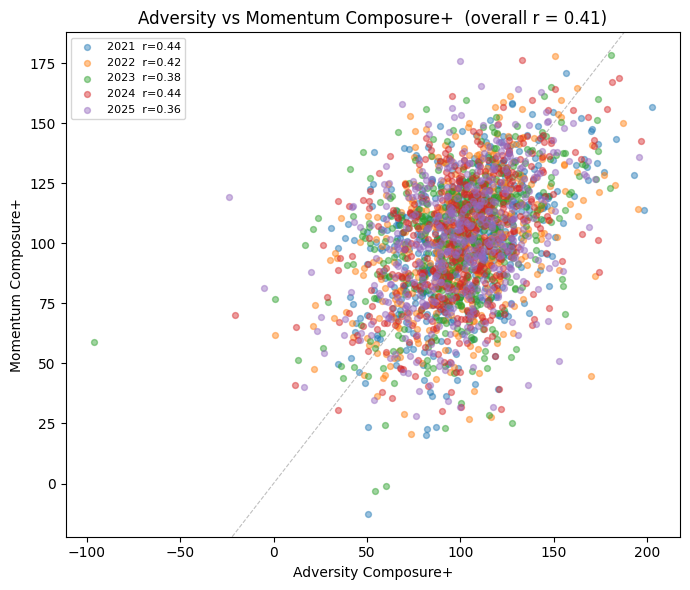

Overall Pearson r = 0.408  (n=2391 pitcher-seasons)


In [237]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Load all scored seasons ───────────────────────────────────────────────────
csvs = [os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv')
        for yr in SEASONS
        if os.path.exists(os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv'))]

if not csvs:
    print('No scored seasons found — run Phase 3 first.')
    all_df, seasons_present = pd.DataFrame(), []
else:
    all_df = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
    seasons_present = sorted(all_df['season'].unique())

    fig, ax = plt.subplots(figsize=(7, 6))
    colors = cm.tab10.colors

    for idx, yr in enumerate(seasons_present):
        sub = all_df[all_df['season'] == yr].dropna(
            subset=['adversity_composure_plus', 'momentum_composure_plus'])
        r = sub[['adversity_composure_plus', 'momentum_composure_plus']].corr().iloc[0, 1]
        ax.scatter(sub['adversity_composure_plus'], sub['momentum_composure_plus'],
                   alpha=0.45, s=18, color=colors[idx % 10], label=f'{yr}  r={r:.2f}')

    overall = all_df.dropna(subset=['adversity_composure_plus', 'momentum_composure_plus'])
    r_all = overall[['adversity_composure_plus', 'momentum_composure_plus']].corr().iloc[0, 1]
    ax.axline((100, 100), slope=1, color='grey', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Adversity Composure+')
    ax.set_ylabel('Momentum Composure+')
    ax.set_title(f'Adversity vs Momentum Composure+  (overall r = {r_all:.2f})')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f'Overall Pearson r = {r_all:.3f}  (n={len(overall)} pitcher-seasons)')


In [238]:
# Depends on all_df and seasons_present defined in Cell A above.
yoy_rows = []
for yr in seasons_present[:-1]:
    cols = ['pitcher_name', 'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus']
    t0 = all_df[all_df['season'] == yr][cols].dropna()
    t1 = all_df[all_df['season'] == yr + 1][cols].dropna()
    merged = t0.merge(t1, on='pitcher_name', suffixes=('_t0', '_t1'))
    if len(merged) < 10:
        continue
    for col in ['composure_plus', 'adversity_composure_plus', 'momentum_composure_plus']:
        r = merged[[f'{col}_t0', f'{col}_t1']].corr().iloc[0, 1]
        yoy_rows.append({'seasons': f'{yr}\u2192{yr+1}', 'metric': col, 'r': round(r, 3), 'n': len(merged)})

if yoy_rows:
    yoy = pd.DataFrame(yoy_rows).pivot(index='seasons', columns='metric', values='r')
    yoy.columns.name = None
    print('Year-over-year Pearson r  (> 0.30 = repeatable skill  |  < 0.15 = mostly noise)\n')
    display(yoy)
else:
    print('Need at least 2 scored consecutive seasons for year-over-year analysis.')


Year-over-year Pearson r  (> 0.30 = repeatable skill  |  < 0.15 = mostly noise)



,adversity_composure_plus,composure_plus,momentum_composure_plus
seasons,,,
2021→2022,0.278,0.425,0.380
2022→2023,0.338,0.400,0.292
2023→2024,0.138,0.345,0.319
2024→2025,0.223,0.471,0.393


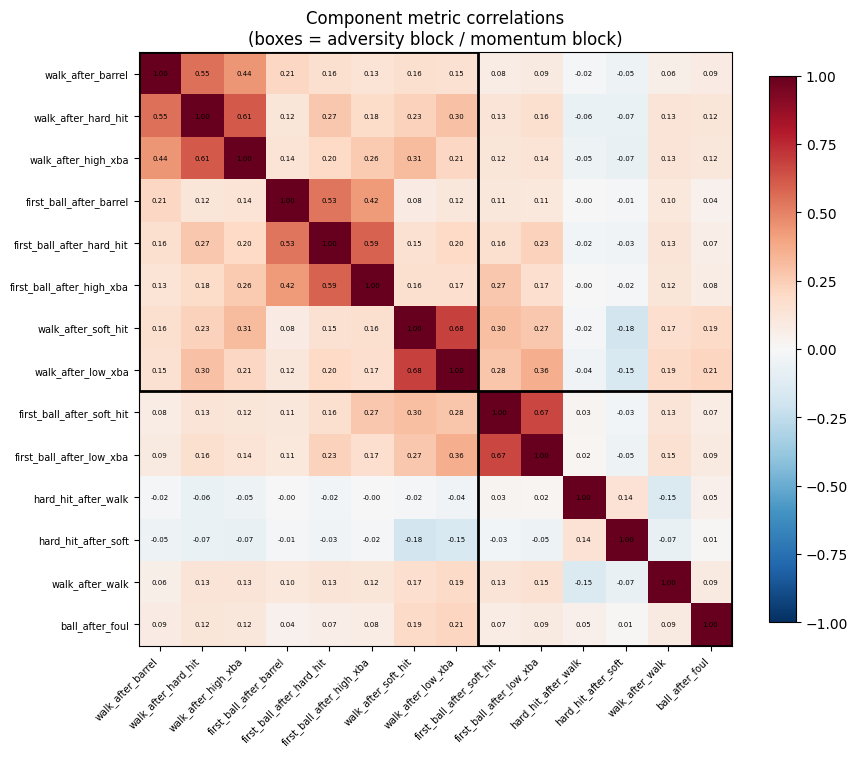

In [239]:
# Depends on seasons_present defined in Cell A above.
metric_dfs = []
for yr in seasons_present:
    path = os.path.join(DATA_DIR, f'pitcher_metrics_{yr}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        df = df[df['pitch_count'] >= MIN_PITCHES]
        metric_dfs.append(df[METRIC_COLS])

if not metric_dfs:
    print('No pitcher_metrics parquets found — run Phase 2 first.')
else:
    combined = pd.concat(metric_dfs, ignore_index=True).dropna(how='all')
    corr = combined.corr()

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(METRIC_COLS)))
    ax.set_yticks(range(len(METRIC_COLS)))
    ax.set_xticklabels(METRIC_COLS, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(METRIC_COLS, fontsize=7)
    for i in range(len(METRIC_COLS)):
        for j in range(len(METRIC_COLS)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                    fontsize=5, color='black')
    # Draw boxes around adversity block and momentum block
    n_adv = len(ADVERSITY_METRICS)
    for block_start, block_size in [(0, n_adv), (n_adv, len(MOMENTUM_METRICS))]:
        rect = plt.Rectangle((block_start - 0.5, block_start - 0.5),
                               block_size, block_size,
                               fill=False, edgecolor='black', lw=2)
        ax.add_patch(rect)
    ax.set_title('Component metric correlations\n(boxes = adversity block / momentum block)')
    plt.tight_layout()
    plt.show()


In [240]:
# Depends on all_df defined in Cell A above.
DIVERGENCE_THRESHOLD = 10  # composure+ points

div = all_df.copy().dropna(subset=['adversity_composure_plus', 'momentum_composure_plus'])
div['divergence'] = div['adversity_composure_plus'] - div['momentum_composure_plus']
show_cols = ['season', 'pitcher_name', 'pitch_count',
             'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus', 'divergence']

print('=== High adversity / low momentum  (bounces back from hard contact; coasts when lucky) ===')
display(
    div[div['divergence'] > DIVERGENCE_THRESHOLD][show_cols]
    .sort_values('divergence', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('\n=== High momentum / low adversity  (stays sharp when lucky; compounds bad events) ===')
display(
    div[div['divergence'] < -DIVERGENCE_THRESHOLD][show_cols]
    .sort_values('divergence')
    .head(15)
    .reset_index(drop=True)
)


=== High adversity / low momentum  (bounces back from hard contact; coasts when lucky) ===


,season,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus,divergence
0,2022,"dunning, dane",2548,99.500,170.200,44.600,125.600
1,2023,"irvin, jake",2149,64.100,127.600,25.400,102.200
2,2025,"civale, aaron",1748,95.900,152.700,51.000,101.700
3,2025,"miller, bryce",1545,80.300,136.200,41.100,95.100
4,2022,"pérez, martín",2979,107.000,157.900,65.400,92.500
5,2024,"jackson, luke",921,65.400,122.100,31.100,91.000
6,2022,"sánchez, aníbal",1240,60.300,116.300,27.700,88.600
7,2023,"peralta, wandy",882,59.700,115.400,28.700,86.700
8,2024,"glasnow, tyler",2012,130.500,174.200,88.000,86.200
9,2025,"senga, kodai",1908,64.000,117.700,31.800,85.900



=== High momentum / low adversity  (stays sharp when lucky; compounds bad events) ===


,season,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus,divergence
0,2023,"kopech, michael",2432,-34.200,-96.400,58.800,-155.200
1,2025,"peralta, freddy",3089,45.500,-23.600,119.300,-142.900
2,2024,"mckenzie, triston",1309,17.600,-20.500,70.200,-90.700
3,2023,"rodriguez, grayson",2104,97.900,48.100,138.100,-90.000
4,2023,"johnson, pierce",1089,89.200,41.200,130.800,-89.600
5,2025,"wheeler, zack",2394,122.000,68.900,158.200,-89.300
6,2023,"de los santos, enyel",1059,66.200,23.900,110.700,-86.800
7,2025,"strider, spencer",2111,30.400,-4.900,81.400,-86.300
8,2023,"abreu, albert",1055,61.400,21.000,105.900,-84.900
9,2021,"maeda, kenta",1776,100.900,53.600,138.000,-84.400
